# VAR Parameter Estimation

The Vector Auto Regressive Process is a generalization of the single variable Autoregressive (AR) process to multiple variables. The $\text{VAR}(n)$ </br> 
is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
\text{Cov}(\mathcal{E}_t, \mathcal{E}_s) = \Omega 
\end{align}
\tag{3}
$

Given a multivariate time series $X_t$ the following parameters are estimated: $\mathcal{M}$, $\Phi_n$ and $\Omega$. Here simulations are performed for specified values of the parameters and estimation methods the take the simulated $X_t$ as input are tested by comparing the result to the values specified .

## Imports

In [52]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats
from lib.plots import stack, fpoints, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [53]:
def comparison_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2, lw=1)

## $\text{VAR}(1)$ Simulations

### Uncoupled $\text{AR}(1)$

In [54]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])

npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [55]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

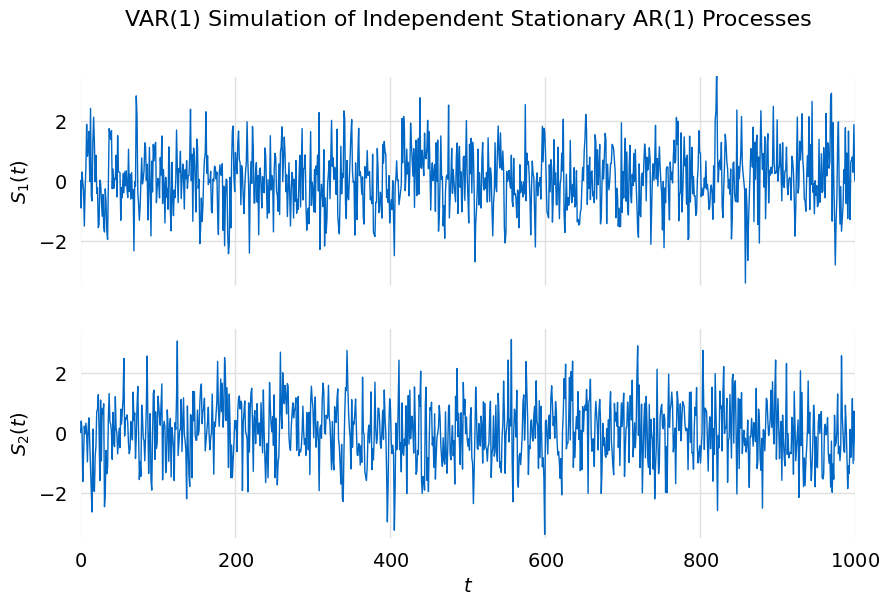

In [56]:
title = f"VAR(1) Simulation of Independent Stationary AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [57]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.09345,0.09606,1.098,0.09437
1,-0.03643*,-0.02860*,0.9642*,-0.03368*
2,-0.03563,-0.02259,0.9650,-0.03106
3,-0.03462,-0.01636,0.9660,-0.02822
4,-0.03334,-0.009859,0.9672,-0.02511


In [58]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "25fae3b0-714d-42bb-869d-90d0f541917f",
   "_VAROrderEst__order": 1,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": -0.03642797001398382,
      "_LagOrderEst__est_id": "25fae3b0-714d-42bb-869d-90d0f541917f"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": -0.028602037822736258,
      "_LagOrderEst__est_id": "25fae3b0-714d-42bb-869d-90d0f541917f"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 0.9642275449699497,
      "_LagOrderEst__est_id": "25fae3b0-714d-42bb-869d-90d0f541917f"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": -0.033684992721891384,
      "_LagOrderEst__est_id": "25fae3b0-714d-42bb-869d-90d0f541917f

In [59]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Nov, 2023
Time:                     11:39:25
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 -0.0289667
Nobs:                     4999.00    HQIC:                -0.0340471
Log likelihood:          -14088.6    FPE:                   0.963880
AIC:                   -0.0367886    Det(Omega_mle):        0.962724
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.010868         0.014015            0.775           0.438
L1.y1         0.236272         0.013744           17.191           0.000
L1.y2        -0.020146         0.013617           -1.479           0.139

Results for equation 

In [60]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.010867907069522263,
         "err": 0.014014742079920954,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "d1e74834-3546-48d1-9d68-5f2a43b61158",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.035607163347859606,
         "err": 0.014038179133613196,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "d1e74834-3546-48d1-9d68-5f2a43b61158",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.23627208293861612,
         "err": 0.013744171286431484,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1

### Coupled $\text{AR}(1)$

In [61]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [62]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

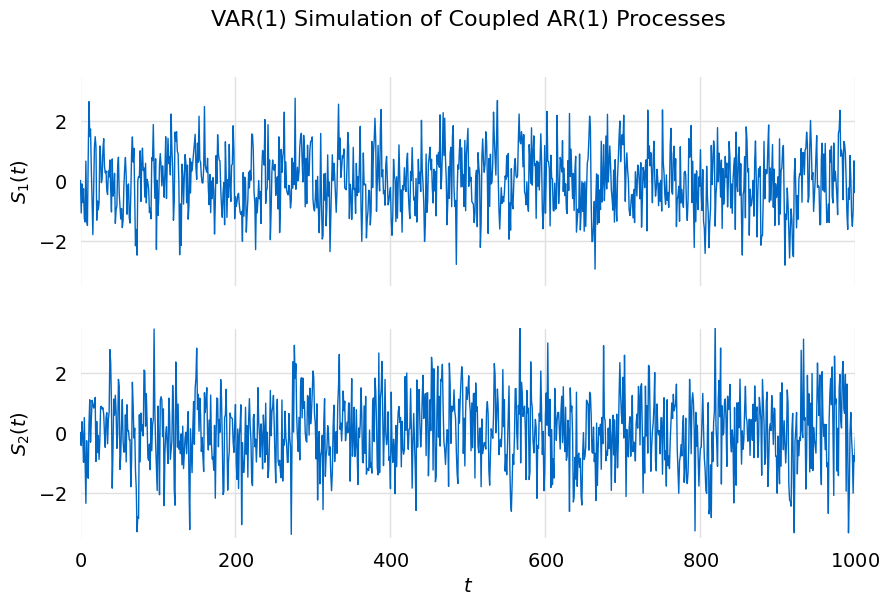

In [63]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [64]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3532,0.3558,1.424,0.3541
1,0.02137*,0.02920*,1.022*,0.02412*
2,0.02268,0.03573,1.023,0.02726
3,0.02355,0.04181,1.024,0.02995
4,0.02401,0.04749,1.024,0.03224


In [65]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "d7f767f4-c9ad-48db-aa8f-9593a48123c3",
   "_VAROrderEst__order": 1,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": 0.02137336111604267,
      "_LagOrderEst__est_id": "d7f767f4-c9ad-48db-aa8f-9593a48123c3"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 0.02919929330729023,
      "_LagOrderEst__est_id": "d7f767f4-c9ad-48db-aa8f-9593a48123c3"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 1.0216034077246665,
      "_LagOrderEst__est_id": "d7f767f4-c9ad-48db-aa8f-9593a48123c3"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 0.024116338408135103,
      "_LagOrderEst__est_id": "d7f767f4-c9ad-48db-aa8f-9593a48123c3"
  

In [66]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Nov, 2023
Time:                     11:39:26
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0285574
Nobs:                     4999.00    HQIC:                 0.0234769
Log likelihood:          -14232.4    FPE:                    1.02095
AIC:                    0.0207354    Det(Omega_mle):         1.01973
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.000284         0.014187            0.020           0.984
L1.y1         0.268016         0.013712           19.546           0.000
L1.y2         0.051255         0.012435            4.122           0.000

Results for equation 

In [67]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.00028447033940655114,
         "err": 0.014186694639132929,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "536297aa-43c5-4e5c-a40d-63fb40ce9ff3",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.014028207768488702,
         "err": 0.014242472074432964,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "536297aa-43c5-4e5c-a40d-63fb40ce9ff3",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.2680164179606411,
         "err": 0.013712118556313917,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 

### Coupled $\text{AR}(1)$ With Non Unit Normal Noise

In [68]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[2.0, 0.2],
                      [0.2, 2.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [69]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

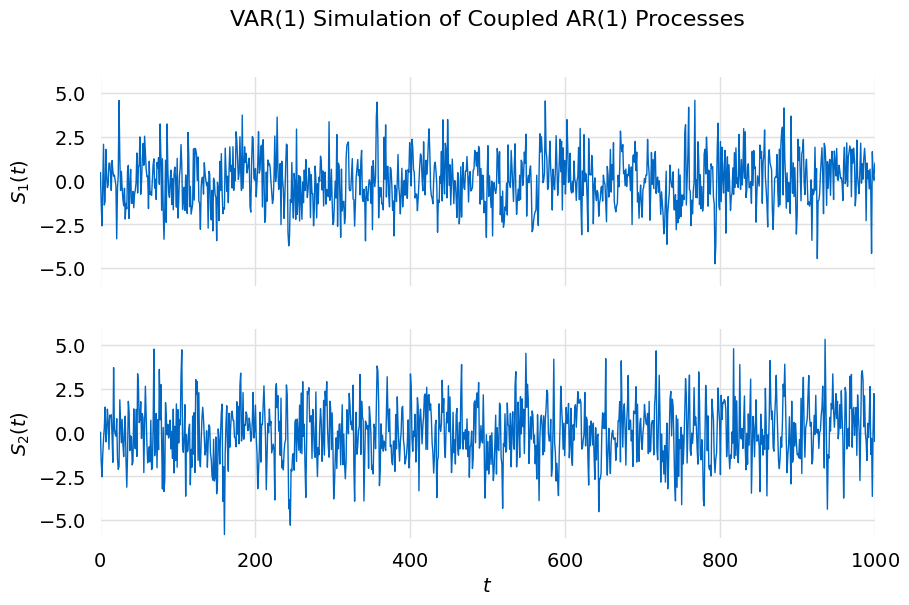

In [70]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [71]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.732,1.735,5.653,1.733
1,1.385*,1.393*,3.994*,1.388*
2,1.386,1.399,3.998,1.390
3,1.387,1.405,4.004,1.394
4,1.388,1.412,4.007,1.396


In [72]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "43fd9992-484e-48b2-8044-b15954fbfd56",
   "_VAROrderEst__order": 1,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": 1.3849057678196248,
      "_LagOrderEst__est_id": "43fd9992-484e-48b2-8044-b15954fbfd56"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 1.3927317000108723,
      "_LagOrderEst__est_id": "43fd9992-484e-48b2-8044-b15954fbfd56"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 3.9944494825504475,
      "_LagOrderEst__est_id": "43fd9992-484e-48b2-8044-b15954fbfd56"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 1,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 1.3876487451117172,
      "_LagOrderEst__est_id": "43fd9992-484e-48b2-8044-b15954fbfd56"
   }
}

In [73]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Nov, 2023
Time:                     11:39:26
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    1.39275
Nobs:                     4999.00    HQIC:                   1.38767
Log likelihood:          -17642.2    FPE:                    3.99452
AIC:                      1.38492    Det(Omega_mle):         3.98973
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.005289         0.020069            0.264           0.792
L1.y1         0.249711         0.013880           17.991           0.000
L1.y2         0.072079         0.012461            5.784           0.000

Results for equation 

In [74]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.005289307202020727,
         "err": 0.0200687963391969,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "602acce5-f4a0-4274-a59d-c6622b6dba03",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.02196590423419625,
         "err": 0.019970751589312875,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "602acce5-f4a0-4274-a59d-c6622b6dba03",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 1,
   "_VAREst__params": [
      {
         "est": 0.24971082275919793,
         "err": 0.013879941288303754,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
 

## $\text{VAR}(2)$ Simulations
### Uncoupled $\text{AR}(2)$

In [75]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]]),
        numpy.matrix([[0.5, 0.0],
                      [0.0, 0.5]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [76]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

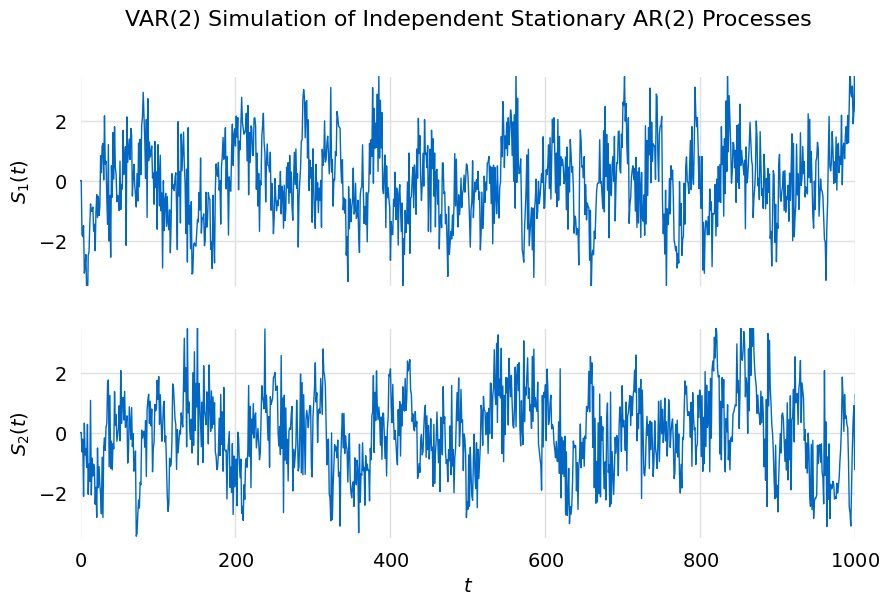

In [77]:
title = f"VAR(2) Simulation of Independent Stationary AR(2) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [78]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,1.236,1.239,3.443,1.237
1,0.6133,0.6211,1.846,0.6160
2,-0.001820*,0.01122*,0.9982*,0.002752*
3,-0.0007489,0.01751,0.9993,0.005651
4,0.0004387,0.02392,1.000,0.008668


In [79]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "33ddf61a-825b-4e99-b4b9-43110ee36700",
   "_VAROrderEst__order": 2,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": -0.0018198107970782392,
      "_LagOrderEst__est_id": "33ddf61a-825b-4e99-b4b9-43110ee36700"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 0.011223409521667695,
      "_LagOrderEst__est_id": "33ddf61a-825b-4e99-b4b9-43110ee36700"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 0.9981818453887084,
      "_LagOrderEst__est_id": "33ddf61a-825b-4e99-b4b9-43110ee36700"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 0.0027518180230758187,
      "_LagOrderEst__est_id": "33ddf61a-825b-4e99-b4b9-43110ee3670

In [80]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Nov, 2023
Time:                     11:39:27
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0115821
Nobs:                     4998.00    HQIC:                0.00311333
Log likelihood:          -14170.1    FPE:                   0.998544
AIC:                  -0.00145665    Det(Omega_mle):        0.996550
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.005934         0.014192            0.418           0.676
L1.y1         0.253160         0.012164           20.813           0.000
L1.y2        -0.011966         0.012154           -0.985           0.325
L2.y1         0.512505

In [81]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.005933935984453866,
         "err": 0.014192196558648926,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "ac63b911-deb2-432b-a72e-c37da364ec02",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.017119138401167612,
         "err": 0.014142655173416094,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "ac63b911-deb2-432b-a72e-c37da364ec02",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 2,
   "_VAREst__params": [
      {
         "est": 0.25316027180787426,
         "err": 0.012163554126968158,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1

### Coupled $\text{AR}(2)$

In [82]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.15],
                      [0.1, 0.1]]),
        numpy.matrix([[0.25, 0.3],
                      [0.2, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [83]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

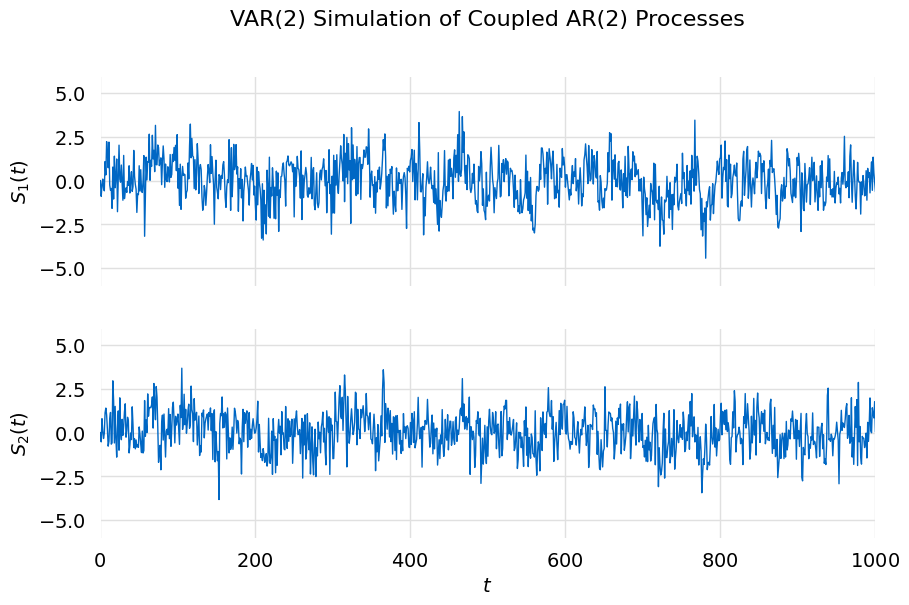

In [84]:
title = f"VAR(2) Simulation of Coupled AR(2) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [85]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.5143,0.5169,1.672,0.5152
1,0.2943,0.3021,1.342,0.2971
2,0.06103,0.07407*,1.063,0.06560*
3,0.06075,0.07901,1.063,0.06715
4,0.05968*,0.08316,1.062*,0.06791


In [86]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "241fcb9e-1c27-4d43-9780-ff00c8046944",
   "_VAROrderEst__order": 2,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 4,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": 0.05968306353288832,
      "_LagOrderEst__est_id": "241fcb9e-1c27-4d43-9780-ff00c8046944"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 0.07407184211793585,
      "_LagOrderEst__est_id": "241fcb9e-1c27-4d43-9780-ff00c8046944"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 4,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 1.0615000734201592,
      "_LagOrderEst__est_id": "241fcb9e-1c27-4d43-9780-ff00c8046944"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 2,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 0.06560025061934398,
      "_LagOrderEst__est_id": "241fcb9e-1c27-4d43-9780-ff00c8046944"
   

In [87]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Nov, 2023
Time:                     11:39:28
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0736410
Nobs:                     4998.00    HQIC:                 0.0651722
Log likelihood:          -14325.2    FPE:                    1.06248
AIC:                    0.0606022    Det(Omega_mle):         1.06035
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.027149         0.014333           -1.894           0.058
L1.y1         0.142853         0.012977           11.008           0.000
L1.y2         0.135719         0.013727            9.887           0.000
L2.y1         0.242274

In [88]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.027148586724170677,
         "err": 0.01433293286732144,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "a942580e-df1d-4527-ae50-ce1cfe2488ee",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.016350560407099535,
         "err": 0.014407185509608322,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "a942580e-df1d-4527-ae50-ce1cfe2488ee",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 2,
   "_VAREst__params": [
      {
         "est": 0.14285303469598581,
         "err": 0.012976654967686225,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1

## $\text{VAR}(3)$ Simulations
### Uncoupled $\text{AR}(3)$

In [89]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.05, 0.0, 0.0],
                      [0.0, 0.1, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
var.compute_is_stationary(phi)
npts=5000
nlag=3

In [90]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

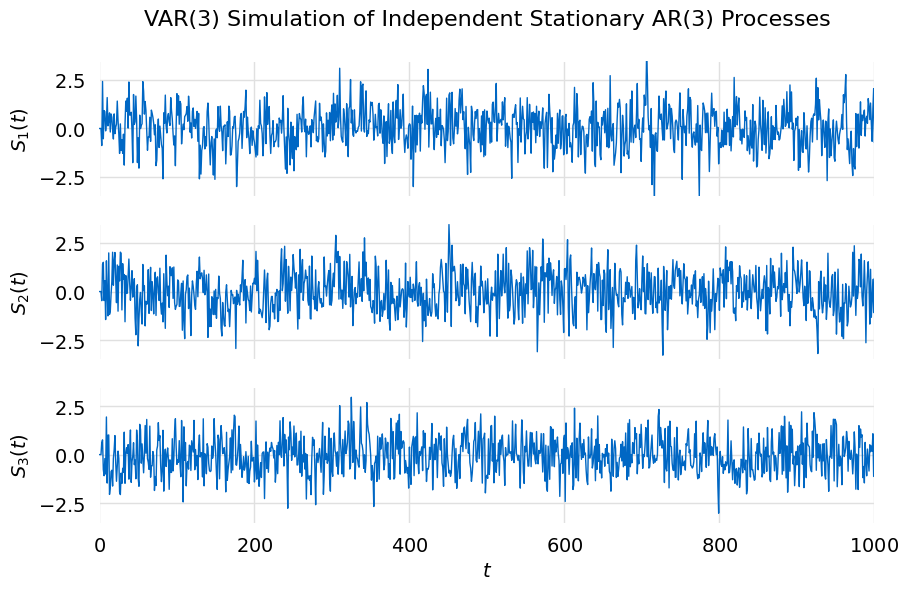

In [91]:
title = f"VAR(3) Simulation of Independent Stationary AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [92]:
result, result_model = var.compute_order_estimate(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.1353,0.1392,1.145,0.1366
1,0.06989,0.08554,1.072,0.07537
2,0.05165,0.07904,1.053,0.06125
3,0.006271*,0.04540*,1.006*,0.01999*
4,0.007462,0.05833,1.007,0.02529


In [93]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "83602372-fd78-40cd-b806-9ab808d96161",
   "_VAROrderEst__order": 3,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": 0.006271152229869233,
      "_LagOrderEst__est_id": "83602372-fd78-40cd-b806-9ab808d96161"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 0.04540081318610704,
      "_LagOrderEst__est_id": "83602372-fd78-40cd-b806-9ab808d96161"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 1.0062908732135678,
      "_LagOrderEst__est_id": "83602372-fd78-40cd-b806-9ab808d96161"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 0.019986038690331408,
      "_LagOrderEst__est_id": "83602372-fd78-40cd-b806-9ab808d96161"
 

In [94]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Nov, 2023
Time:                     11:39:28
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0450694
Nobs:                     4997.00    HQIC:                 0.0196588
Log likelihood:          -21256.2    FPE:                    1.00596
AIC:                   0.00594634    Det(Omega_mle):        0.999949
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.026711         0.014154            1.887           0.059
L1.y1         0.166222         0.014013           11.862           0.000
L1.y2        -0.007038         0.014035           -0.501           0.616
L1.y3         0.003908

In [95]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.026710959909784112,
         "err": 0.014154054696861602,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "c016f579-b653-4e05-9860-67a465494a05",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.003774345493841268,
         "err": 0.014116154882165059,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "c016f579-b653-4e05-9860-67a465494a05",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.001547183931834402,
         "err": 0.014254985300987927,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 2,
         "order": 1,
         "est_id": "c016f579-b653-4e05-9860-67a465494a05

### Coupled $\text{AR}(3)$

In [109]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.1, 0.2],
                      [0.0, 0.15, 0.1],
                      [0.05, 0.025, 0.05]]),
        numpy.matrix([[0.015, 0.01, 0.0],
                      [0.1, 0.1, 0.05],
                      [0.1, 0.05, 0.05]]),
        numpy.matrix([[0.15, 0.05, 0.1],
                      [0.0, 0.15, 0.025],
                      [0.025, 0.15, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
npts=5000
nlag=3
var.compute_is_stationary(phi)


True

In [104]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

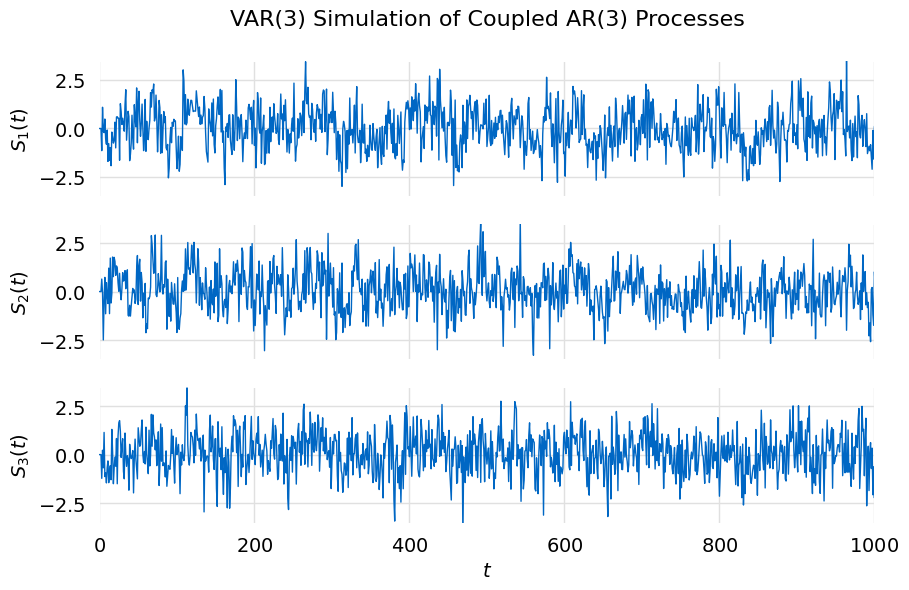

In [105]:
title = f"VAR(3) Simulation of Coupled AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [110]:
result, result_model = var.compute_order_estimate(xt, maxlags=5)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.4041,0.4081,1.498,0.4055
1,0.1443,0.1599,1.155,0.1498
2,0.06455,0.09194,1.067,0.07415
3,-0.01037*,0.02876*,0.9897*,0.003343*
4,-0.009269,0.04161,0.9908,0.008563
5,-0.007901,0.05472,0.9921,0.01405


In [111]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderEst__est_id": "b0d96a56-5d00-47e3-94e6-32d1f0bce78a",
   "_VAROrderEst__order": 3,
   "_VAROrderEst__aic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "AIC",
      "_LagOrderEst__value": -0.010374339168327494,
      "_LagOrderEst__est_id": "b0d96a56-5d00-47e3-94e6-32d1f0bce78a"
   },
   "_VAROrderEst__bic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "BIC",
      "_LagOrderEst__value": 0.028761953270607363,
      "_LagOrderEst__est_id": "b0d96a56-5d00-47e3-94e6-32d1f0bce78a"
   },
   "_VAROrderEst__fpe": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "FPE",
      "_LagOrderEst__value": 0.9896793045594001,
      "_LagOrderEst__est_id": "b0d96a56-5d00-47e3-94e6-32d1f0bce78a"
   },
   "_VAROrderEst__hqic": {
      "_LagOrderEst__order": 3,
      "_LagOrderEst__error_metric": "HQIC",
      "_LagOrderEst__value": 0.003343010666176805,
      "_LagOrderEst__est_id": "b0d96a56-5d00-47e3-94e6-32d1f0bce78a"

In [112]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 19, Nov, 2023
Time:                     12:01:24
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0286644
Nobs:                     4997.00    HQIC:                0.00325376
Log likelihood:          -21215.2    FPE:                   0.989596
AIC:                   -0.0104587    Det(Omega_mle):        0.983678
--------------------------------------------------------------------
Results for equation y1
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.016643         0.014058            1.184           0.236
L1.y1         0.153911         0.013891           11.080           0.000
L1.y2         0.122203         0.014037            8.706           0.000
L1.y3         0.197187

In [102]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.01186646761445517,
         "err": 0.014187521884395388,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "2a62dee6-6e65-4eab-b0a4-2e14ccd0d3a0",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.027329510148840837,
         "err": 0.014141280355544062,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "2a62dee6-6e65-4eab-b0a4-2e14ccd0d3a0",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.01329887474108157,
         "err": 0.014649347807143455,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 2,
         "order": 1,
         "est_id": "2a62dee6-6e65-4eab-b0a4-2e14ccd0d3a0